# Automated speed metric acquisition

This notebook combines the new detector DATA flow from notebook 17 with the simple contrast metric from `speed_metric`.

The experiment takes one large overview image, spaces the experiment boxes across the center of the field, tracks the contrast window, moves each scan region up and down, and plots distance vs time for each dwell time.

### Quick Start Code Cell

In [1]:
import os
import json
import time
from getpass import getpass

import tango
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, gaussian_filter1d
from tiled.client import from_uri

%matplotlib ipympl

## 0. Ping Tango servers

In [2]:
DB_HOST = '10.46.217.241'
DB_PORT = 9094

os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"

server_names = ["stage", "scan", "eds", "camera", "data", "microscope"]

for name in server_names:
    device_name = f"asyncroscopy/{name}/default"
    proxy = tango.DeviceProxy(device_name)
    proxy.ping()
    print(device_name, proxy.state())

asyncroscopy/stage/default ON
asyncroscopy/scan/default ON
asyncroscopy/eds/default ON
asyncroscopy/camera/default ON
asyncroscopy/data/default ON
asyncroscopy/microscope/default ON


## 1. Connect to devices

In [3]:
SCAN_DEVICE = "asyncroscopy/scan/default"
MICROSCOPE_DEVICE = "asyncroscopy/microscope/default"
DATA_DEVICE = "asyncroscopy/data/default"

In [4]:
scan = tango.DeviceProxy(SCAN_DEVICE)
microscope = tango.DeviceProxy(MICROSCOPE_DEVICE)
data = tango.DeviceProxy(DATA_DEVICE)

for proxy in (scan, microscope, data):
    proxy.set_timeout_millis(120_000)

print("scan      :", scan.state())
print("microscope:", microscope.state())
print("data      :", data.state())

scan      : ON
microscope: ON
data      : ON


In [5]:
TILED_HOST = "10.46.217.241"
TILED_PORT = 9091
# save_path = "/Users/austin/Desktop/new_data/"
save_path = "D:/microscopedata/tiled/ahoust17/2026_05_22_AtomFab/"

data.host = TILED_HOST
data.port = TILED_PORT
data.save_path = save_path


api_key = getpass("Enter your Tiled API key: ")
data.set_api_key(api_key)

data.start_tiled_server()


'{"host": "10.46.217.241", "port": 9091, "uri": "http://10.46.217.241:9091", "save_path": "D:/microscopedata/tiled/ahoust17/2026_05_22_AtomFab/", "root_path": "D:/microscopedata/tiled/ahoust17/2026_05_22_AtomFab", "api_key_configured": true, "tiled_server": "yes", "tiled_server_status": "running; watcher active"}'

In [6]:

client = from_uri(f"http://{TILED_HOST}:{TILED_PORT}", api_key=api_key)
list(client)

['D:']

## 2. Take an overview image

In [7]:
scan.Activate(["haadf"])
scan.haadf = True
scan.bf = False

overview_imsize = 2048
overview_dwell_time = 5e-6

scan.imsize = overview_imsize
scan.dwell_time = overview_dwell_time
scan.scan_region = [0, 0, 1, 1]

print("imsize     :", scan.imsize)
print("dwell_time :", scan.dwell_time)
print("scan_region:", list(scan.scan_region))

imsize     : 2048
dwell_time : 5e-06
scan_region: [np.float64(0.0), np.float64(0.0), np.float64(1.0), np.float64(1.0)]


(np.float64(-0.5), np.float64(2047.5), np.float64(2047.5), np.float64(-0.5))

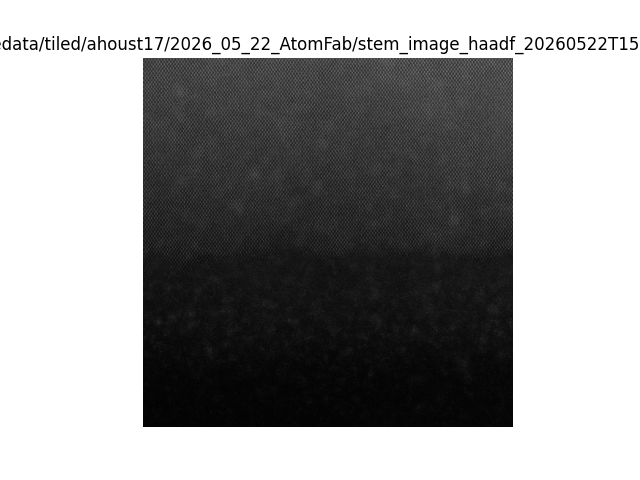

In [15]:
key = microscope.get_scanned_image_advanced()
time.sleep(4)

overview = np.asarray(client[key].read())


plt.figure()
plt.imshow(overview, cmap="gray")
plt.title(key)
plt.axis("off")

## 3. Lay out experiment regions

[{'dwell_time': 0.0001,
  'left': 0.07499999999999996,
  'top': 0.505,
  'width': 0.1,
  'height': 0.03},
 {'dwell_time': 0.0002,
  'left': 0.32499999999999996,
  'top': 0.505,
  'width': 0.1,
  'height': 0.03},
 {'dwell_time': 0.0005,
  'left': 0.575,
  'top': 0.505,
  'width': 0.1,
  'height': 0.03},
 {'dwell_time': 0.001,
  'left': 0.825,
  'top': 0.505,
  'width': 0.1,
  'height': 0.03}]

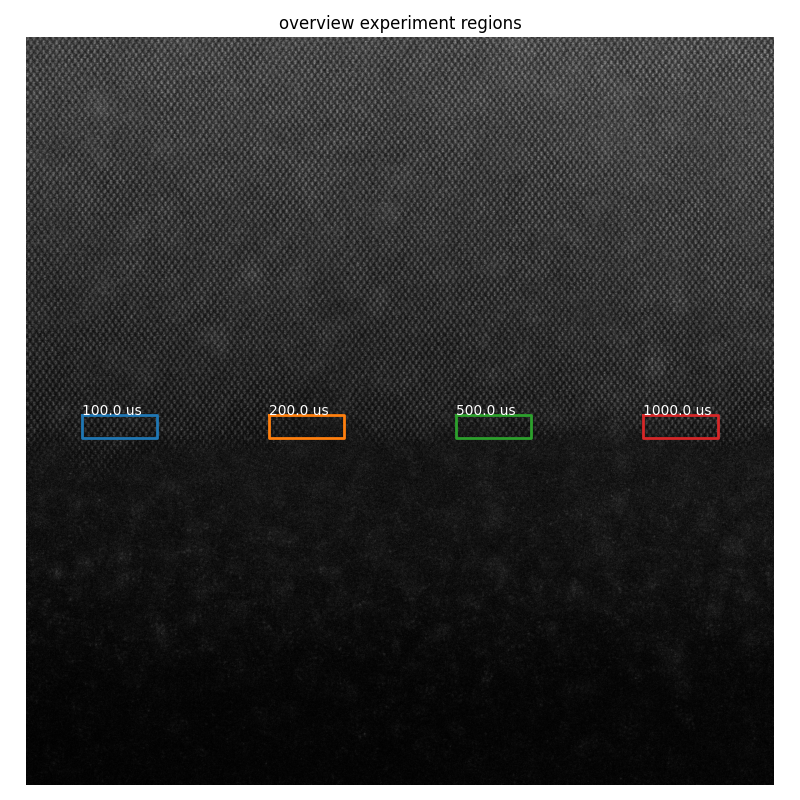

In [18]:
dwell_times = [100e-6, 200e-6, 500e-6, 1000e-6]

experiment_width = 0.10
experiment_height = 0.03
experiment_gap = 1.5 * experiment_width
experiment_pitch = experiment_width + experiment_gap

total_width = len(dwell_times) * experiment_width + (len(dwell_times) - 1) * experiment_gap
first_left = 0.5 - total_width / 2
center_y = 0.52

experiment_regions = []

for i, dwell_time in enumerate(dwell_times):
    left = first_left + i * experiment_pitch
    top = center_y - experiment_height / 2
    experiment_regions.append({"dwell_time": dwell_time, "left": left, "top": top, "width": experiment_width, "height": experiment_height})

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(overview, cmap="gray")

for region in experiment_regions:
    x0 = region["left"] * overview.shape[1]
    x1 = (region["left"] + region["width"]) * overview.shape[1]
    y0 = region["top"] * overview.shape[0]
    y1 = (region["top"] + region["height"]) * overview.shape[0]
    ax.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], linewidth=2)
    ax.text(x0, y0, f"{region['dwell_time'] * 1e6:.1f} us", color="white")

ax.set_title("overview experiment regions")
ax.axis("off")
plt.tight_layout()

experiment_regions

## 4. Automated scan-speed sweep

In [19]:
n_frames = 10
sleep_time = 0.5

imsize = 512
tracker_gain = 0.5
x_center = imsize // 2
size_x = 128

results = []
last_images = {}

for region in experiment_regions:
    dwell_time = region["dwell_time"]
    left = region["left"]
    top = region["top"]
    width = region["width"]
    height = region["height"]
    start_top = top
    start_time = time.time()
    scan_speed_px_s = 1 / dwell_time
    scan_speed_lines_s = 1 / (dwell_time * imsize)

    for frame in range(n_frames):
        scan.imsize = imsize
        scan.dwell_time = dwell_time
        scan.scan_region = [left, top, width, height]

        key = microscope.get_scanned_image_advanced()
        elapsed_s = time.time() - start_time
        time.sleep(sleep_time)

        image = np.asarray(client[key].read())

        if image.ndim == 3:
            image = image[..., :3].mean(axis=2)

        img = image.astype(float)
        img = gaussian_filter(img, sigma=1)
        img -= img.min()

        if img.max() > 0:
            img /= img.max()

        x0 = max(0, x_center - size_x // 2)
        x1 = min(img.shape[1], x_center + size_x // 2)
        crop = img[:, x0:x1]
        line_metric = crop.std(axis=1)
        line_metric = gaussian_filter1d(line_metric, sigma=2)
        metric_y = int(np.argmax(line_metric))

        target_y = img.shape[0] // 2
        window_distance_rel = top - start_top
        window_distance_pix = window_distance_rel * overview.shape[0]
        metric_offset_pix = metric_y - target_y

        results.append({"dwell_time": dwell_time,
                        "scan_speed_px_s": scan_speed_px_s,
                        "scan_speed_lines_s": scan_speed_lines_s,
                        "frame": frame,
                        "time_s": elapsed_s,
                        "key": key,
                        "left": left,
                        "top": top,
                        "width": width,
                        "height": height,
                        "metric_y": metric_y,
                        "metric_offset_pix": metric_offset_pix,
                        "window_distance_rel": window_distance_rel,
                        "window_distance_pix": window_distance_pix})

        top += tracker_gain * metric_offset_pix / img.shape[0] * height
        top = min(max(top, 0), 1 - height)
        last_images[dwell_time] = img

        print(dwell_time, frame, key, "metric_y", metric_y, "next_top", top)

len(results)

0.0001 0 D:/microscopedata/tiled/ahoust17/2026_05_22_AtomFab/stem_image_haadf_20260522T155247116118.tiff metric_y 0 next_top 0.498
0.0001 1 D:/microscopedata/tiled/ahoust17/2026_05_22_AtomFab/stem_image_haadf_20260522T155248856183.tiff metric_y 0 next_top 0.491
0.0001 2 D:/microscopedata/tiled/ahoust17/2026_05_22_AtomFab/stem_image_haadf_20260522T155250498551.tiff metric_y 0 next_top 0.484
0.0001 3 D:/microscopedata/tiled/ahoust17/2026_05_22_AtomFab/stem_image_haadf_20260522T155252159972.tiff metric_y 0 next_top 0.477
0.0001 4 D:/microscopedata/tiled/ahoust17/2026_05_22_AtomFab/stem_image_haadf_20260522T155253994355.tiff metric_y 0 next_top 0.47
0.0001 5 D:/microscopedata/tiled/ahoust17/2026_05_22_AtomFab/stem_image_haadf_20260522T155255748523.tiff metric_y 0 next_top 0.46299999999999997
0.0001 6 D:/microscopedata/tiled/ahoust17/2026_05_22_AtomFab/stem_image_haadf_20260522T155257367604.tiff metric_y 0 next_top 0.45599999999999996
0.0001 7 D:/microscopedata/tiled/ahoust17/2026_05_22_Ato

40

## 5. Distance vs time

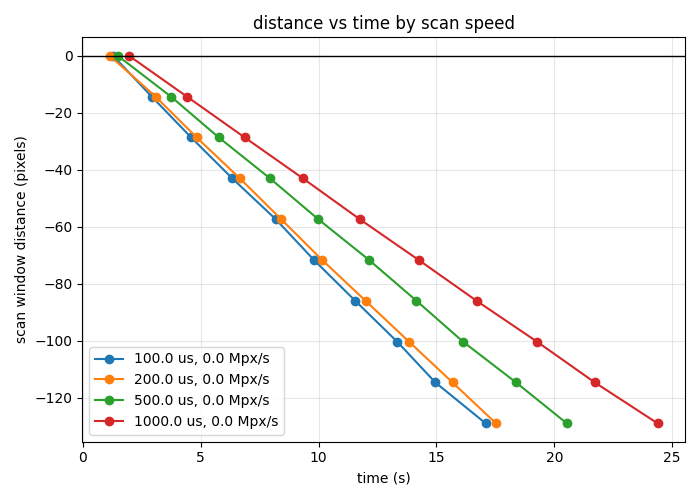

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))

for dwell_time in dwell_times:
    rows = [r for r in results if r["dwell_time"] == dwell_time]
    times = np.array([r["time_s"] for r in rows])
    distances = np.array([r["window_distance_pix"] for r in rows])
    scan_speed = rows[0]["scan_speed_px_s"]
    label = f"{dwell_time * 1e6:.1f} us, {scan_speed / 1e6:.1f} Mpx/s"

    ax.plot(times, distances, marker="o", label=label)

ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("time (s)")
ax.set_ylabel("scan window distance (pixels)")
ax.set_title("distance vs time by scan speed")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

In [21]:
for dwell_time in dwell_times:
    rows = [r for r in results if r["dwell_time"] == dwell_time]
    times = np.array([r["time_s"] for r in rows])
    distances = np.array([r["window_distance_pix"] for r in rows])

    if len(times) > 1 and np.ptp(times) > 0:
        speed_pix_s = np.polyfit(times, distances, 1)[0]
        print(f"dwell {dwell_time * 1e6:.1f} us: window speed {speed_pix_s:.3f} px/s")

dwell 100.0 us: window speed -8.225 px/s
dwell 200.0 us: window speed -7.925 px/s
dwell 500.0 us: window speed -6.825 px/s
dwell 1000.0 us: window speed -5.775 px/s


(np.float64(-0.5), np.float64(2047.5), np.float64(2047.5), np.float64(-0.5))

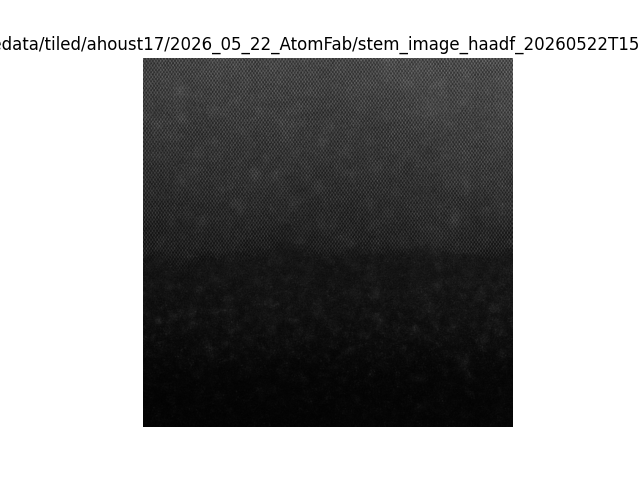

In [22]:
scan.imsize = overview_imsize
scan.dwell_time = overview_dwell_time
scan.scan_region = [0, 0, 1, 1]

key = microscope.get_scanned_image_advanced()
time.sleep(4)

overview = np.asarray(client[key].read())


plt.figure()
plt.imshow(overview, cmap="gray")
plt.title(key)
plt.axis("off")